This project uses the NYC Rolling Sales dataset, which contains detailed information about building sales in New York City over a 12-month period. I was interested in this data because it offers insight into real estate trends across different neighborhoods in NYC and allows for an analysis of how location and property size affect sale prices. The dataset was originally sourced from Kaggle and can be downloaded directly from the following link:[NYC Property Sales](https://www.kaggle.com/datasets/new-york-city/nyc-property-sales/data)

---



The data was originally collected by the New York City Department of Finance and includes variables such as borough, neighborhood, building class, land square feet, gross square feet, sale price, and sale date. This dataset provides a rich foundation for exploring housing patterns and understanding the dynamics of property values across New York City.




In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Data Description & Assessment

In [2]:
nyc_property_sales = pd.read_csv('https://raw.githubusercontent.com/Mustak-Eman/NYC-Property-Sales-EDA/refs/heads/main/nyc-rolling-sales.csv')
nyc_property_sales.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


Before analyzing the dataset, I performed several data cleaning steps to ensure the information was accurate and ready for analysis. In this dataset, missing values were represented by " - " (a space, a dash, or two spaces), so I replaced these entries with proper NaN values and then removed any rows containing missing data. I also checked for and removed duplicate rows to avoid counting the same sale more than once. Next, I cleaned the quantitative columns, such as SALE PRICE, LAND SQUARE FEET, and GROSS SQUARE FEET, by removing any extra characters and converting them from text strings to numeric data types. I then converted the SALE DATE column to a proper date format using pd.to_datetime(). After these steps, the dataset contained only clean, valid values and was ready for exploratory analysis.

In [3]:
nyc_property_sales.shape           # rows, columns

(84548, 22)

In [4]:
nyc_property_sales.info()         # column names, data types, missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

In [5]:
nyc_property_sales.describe()     # summary stats for numeric columns

,Unnamed: 0,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE
count,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000
mean,10344.359878,2.998758,4237.218976,376.224015,10731.991614,2.025264,0.193559,2.249184,1789.322976,1.657485
std,7151.779436,1.289790,3568.263407,658.136814,1290.879147,16.721037,8.713183,18.972584,537.344993,0.819341
min,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4231.000000,2.000000,1322.750000,22.000000,10305.000000,0.000000,0.000000,1.000000,1920.000000,1.000000
50%,8942.000000,3.000000,3311.000000,50.000000,11209.000000,1.000000,0.000000,1.000000,1940.000000,2.000000
75%,15987.250000,4.000000,6281.000000,1001.000000,11357.000000,2.000000,0.000000,2.000000,1965.000000,2.000000
max,26739.000000,5.000000,16322.000000,9106.000000,11694.000000,1844.000000,2261.000000,2261.000000,2017.000000,4.000000


In [6]:
nyc_property_sales.replace(' -  ', np.nan, inplace=True)
nyc_property_sales.dropna(inplace=True)
nyc_property_sales.drop_duplicates(inplace=True)

In [7]:
nyc_property_sales.columns = nyc_property_sales.columns.str.strip().str.lower().str.replace(' ', '_')

In [8]:
nyc_property_sales['sale_price'] = nyc_property_sales['sale_price'].str.replace('$', '').str.replace(',', '').astype(float)

In [9]:
nyc_property_sales['land_square_feet'] = nyc_property_sales['land_square_feet'].str.replace(',', '').astype(float)

In [10]:
nyc_property_sales['gross_square_feet'] = nyc_property_sales['gross_square_feet'].str.replace(',', '').astype(float)

In [11]:
nyc_property_sales['sale_date'] = pd.to_datetime(nyc_property_sales['sale_date'])

In [12]:
nyc_property_sales.shape

(48244, 22)

### Single variable distribution plots

In [13]:
clean_prices = nyc_property_sales['sale_price']
clean_prices = clean_prices[(clean_prices >= 20000) & (clean_prices <= 2000000)]


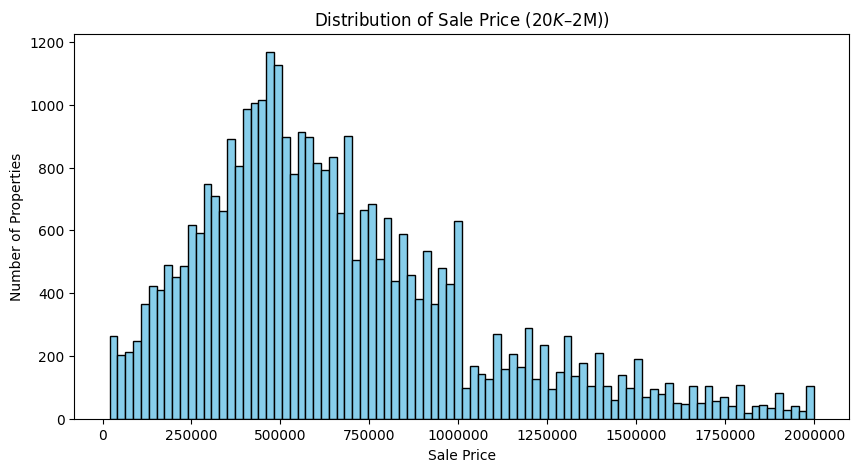

In [14]:
plt.figure(figsize=(10,5))
plt.hist(clean_prices, bins=90, color='skyblue', edgecolor='black')
plt.title("Distribution of Sale Price ($20K – $2M))")
plt.xlabel("Sale Price")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style='plain', axis='x')
plt.show()


The histogram above shows the distribution of sale prices for properties in New York City between $20,000 and $2,000,000. The shape of the distribution is right-skewed, meaning that most properties sold at lower prices, while only a few were sold at higher prices. The highest concentration of sales occurs around $400,000 to $800,000, and the frequency of sales decreases as prices rise.

In [15]:
clean_gross_square_feet = nyc_property_sales['gross_square_feet']
clean_gross_square_feet = clean_gross_square_feet[(clean_gross_square_feet >= 100) & (clean_gross_square_feet <= 8000)]

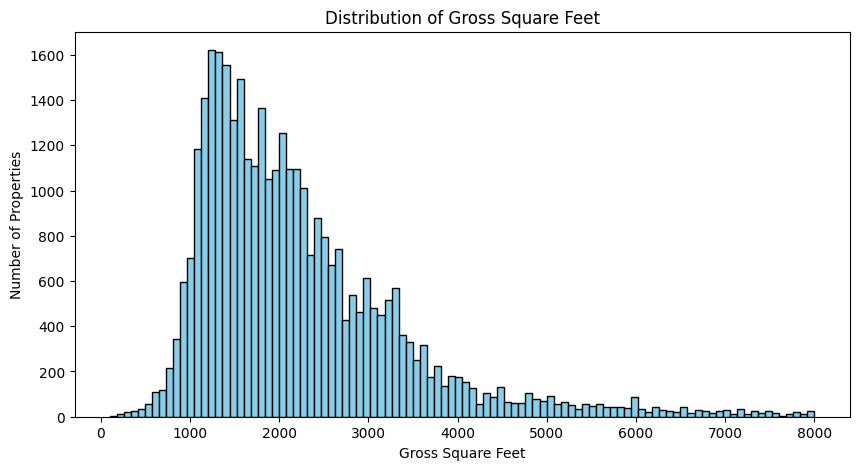

In [16]:
plt.figure(figsize=(10,5))
plt.hist(clean_gross_square_feet, bins=100, color='skyblue', edgecolor='black')
plt.title("Distribution of Gross Square Feet")
plt.xlabel("Gross Square Feet")
plt.ylabel("Number of Properties")
plt.show()

The distribution of gross square feet is right-skewed, with most properties between 1,000 and 2,500 square feet. A few buildings are much larger, creating a long tail on the right side. This shows that smaller residential properties are far more common in NYC, while large buildings make up only a small portion of the dataset.

In [17]:
clean_land_square_feet = nyc_property_sales['land_square_feet']
clean_land_square_feet = clean_land_square_feet[(clean_land_square_feet >= 100) & (clean_land_square_feet <= 6000)]

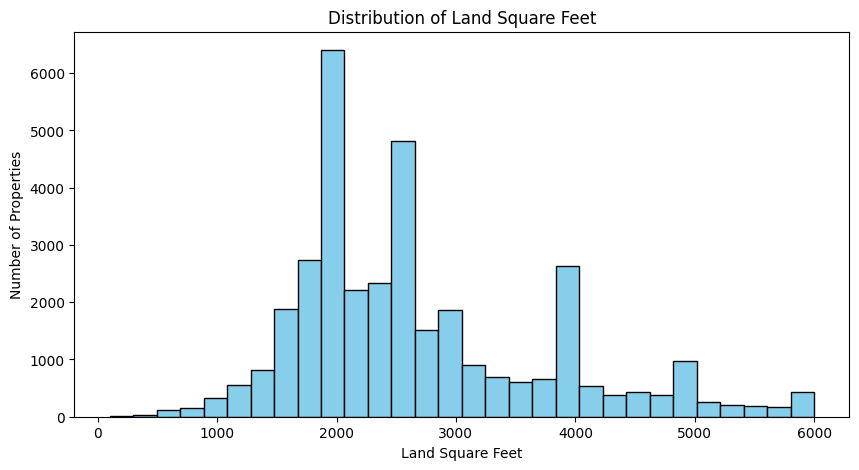

In [18]:
plt.figure(figsize=(10,5))
plt.hist(clean_land_square_feet, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Land Square Feet")
plt.xlabel("Land Square Feet")
plt.ylabel("Number of Properties")
plt.show()

The distribution of land square feet is right-skewed, with most properties having between 1,500 and 3,000 square feet of land. There are a few larger lots that extend the tail to the right. This pattern shows that smaller plots are much more common in New York City, while large parcels of land are relatively rare.

In [19]:
clean_year_built = nyc_property_sales['year_built']
clean_year_built = clean_year_built[(clean_year_built >= 1800) & (clean_year_built <= 2023)]

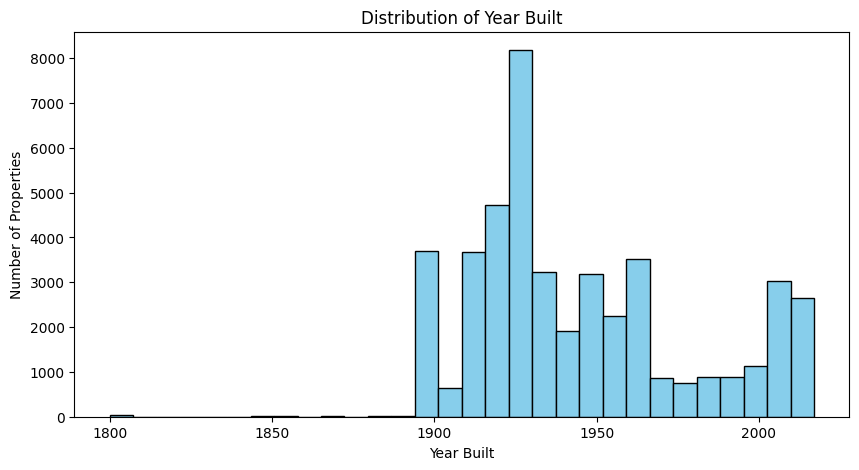

In [20]:
plt.figure(figsize=(10,5))
plt.hist(clean_year_built, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Number of Properties")
plt.show()

The distribution of year built shows that most properties were constructed between 1900 and 1960, with a noticeable peak around the 1920s. Fewer buildings were built before 1900 or after 2000.

### Multiple variable plots

In [21]:
nyc_property_sales['neighborhood'] = nyc_property_sales['neighborhood'].str.upper().str.strip()

selected = ['SUNSET PARK', 'BENSONHURST', 'ASTORIA']
clean_nyc = nyc_property_sales[
    nyc_property_sales['sale_price'].between(20_000, 2_000_000)
    & nyc_property_sales['gross_square_feet'].between(0, 8_000)
    & nyc_property_sales['land_square_feet'].between(0, 16_000)
    & nyc_property_sales['year_built'].between(1800, 2023)
    & nyc_property_sales['neighborhood'].isin(selected)
].copy()

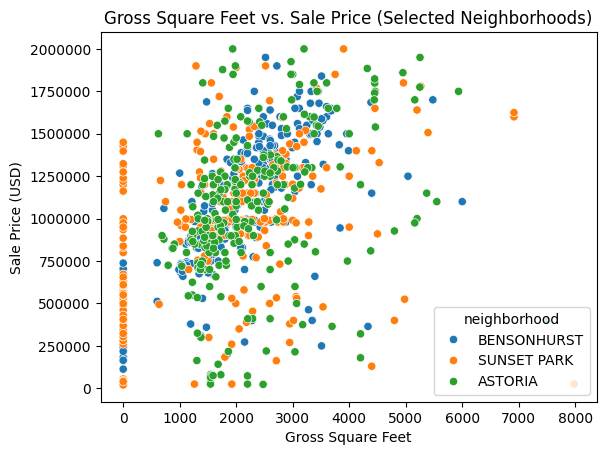

In [22]:
sns.scatterplot(data=clean_nyc, x='gross_square_feet', y='sale_price',hue=clean_nyc['neighborhood'])
plt.title("Gross Square Feet vs. Sale Price (Selected Neighborhoods)")
plt.xlabel("Gross Square Feet")
plt.ylabel("Sale Price (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

This scatterplot compares property sale prices and gross square footage for homes in Bensonhurst, Sunset Park, and Astoria.

There is a positive relationship — larger properties tend to sell for higher prices in all three neighborhoods.

/tmp/ipython-input-2953536932.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


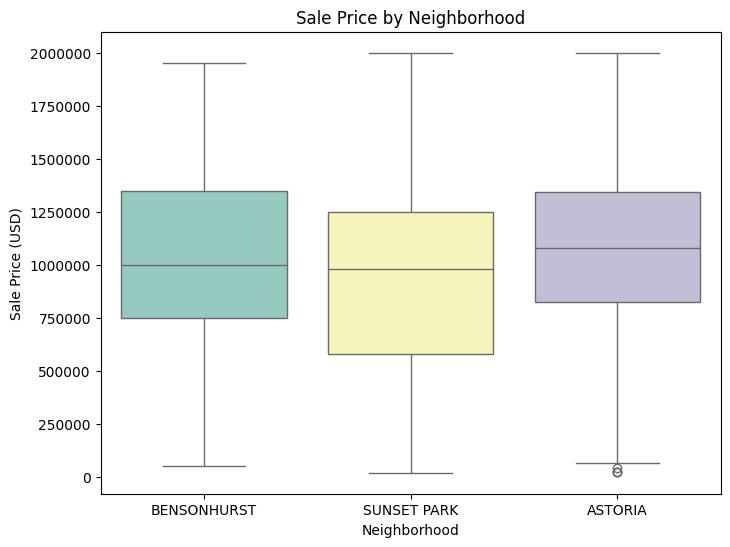

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=clean_nyc,
    x='neighborhood',
    y='sale_price',
    palette='Set3'
)
plt.title("Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price (USD)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


This boxplot compares property sale prices in Bensonhurst, Sunset Park, and Astoria.
All three neighborhoods have similar overall price ranges, but Astoria shows a slightly higher median and broader distribution, indicating more variation in property values.
Bensonhurst and Sunset Park have tighter price ranges, suggesting more consistent mid-level home prices.
A few low-value outliers appear in Astoria, likely representing smaller or older properties.

#Predicting Property Sale Prices With Machine Learning Models

In [24]:
clean_nyc = nyc_property_sales[
    (nyc_property_sales['sale_price'].between(20000, 2000000)) &
    (nyc_property_sales['gross_square_feet'].between(100, 8000)) &
    (nyc_property_sales['land_square_feet'].between(100, 6000)) &
    (nyc_property_sales['year_built'].between(1800, 2023)) &
    (nyc_property_sales['neighborhood'].notna())
].copy()


###Model 1: Linear Regression

In [25]:
linear_df = clean_nyc.copy()

In [26]:
linear_dummy = pd.get_dummies(linear_df['neighborhood'], drop_first=True)
linear_df = pd.concat([linear_df, linear_dummy], axis=1)


In [27]:
linear_model = smf.ols("sale_price ~ gross_square_feet + land_square_feet + year_built + C(neighborhood)", data = linear_df).fit()
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             sale_price   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     151.1
Date:                Fri, 19 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:26:54   Log-Likelihood:            -3.3766e+05
No. Observations:               24486   AIC:                         6.758e+05
Df Residuals:                   24264   BIC:                         6.776e+05
Df Model:                         221                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                     -1.02e+06   1.74e+05     -5.849      0.000   -1.36e+06   -6.78e+05
C(neighborhood)[T.ANNADALE]                   -3.39e+05   1.21e+05     -2.794      0.005   -5.77e+05   -1.01e+05
C(neighborhood)[T.ARDEN HEIGHTS]             -3.996e+05    1.2e+05     -3.341      0.001   -6.34e+05   -1.65e+05
C(neighborhood)[T.ARROCHAR]                  -3.596e+05   1.29e+05     -2.781      0.005   -6.13e+05   -1.06e+05
C(neighborhood)[T.ARROCHAR-SHORE ACRES]      -3.738e+05   1.35e+05     -2.759      0.006   -6.39e+05   -1.08e+05
C(neighborhood)[T.ARVERNE]                   -5.001e+05    1.2e+05     -4.157      0.000   -7.36e+05   -2.64e+05
C(neighborhood)[T.ASTORIA]                     1.84e+05   1.19e+05      1.541      0.123   -5.01e+04    4.18e+05
C(neighborhood)[T.BATH BEACH]                  1.56e+05   1.21e+05      1.289      0.197   -8.12e+04    3.93e+05
C(neighborhood)[T.BATHGATE]                   -4.74e+05   1.26e+05     -3.757      0.000   -7.21e+05   -2.27e+05
C(neighborhood)[T.BAY RIDGE]                  2.076e+05    1.2e+05      1.737      0.082   -2.66e+04    4.42e+05
C(neighborhood)[T.BAYCHESTER]                -4.555e+05   1.19e+05     -3.816      0.000   -6.89e+05   -2.21e+05
C(neighborhood)[T.BAYSIDE]                     915.4564   1.19e+05      0.008      0.994   -2.33e+05    2.34e+05
C(neighborhood)[T.BEDFORD PARK/NORWOOD]        -4.1e+05   1.21e+05     -3.375      0.001   -6.48e+05   -1.72e+05
C(neighborhood)[T.BEDFORD STUYVESANT]          2.25e+05   1.19e+05      1.890      0.059   -8295.332    4.58e+05
C(neighborhood)[T.BEECHHURST]                -3.109e+04   1.25e+05     -0.248      0.804   -2.77e+05    2.14e+05
C(neighborhood)[T.BELLE HARBOR]              -9.137e+04   1.22e+05     -0.747      0.455   -3.31e+05    1.48e+05
C(neighborhood)[T.BELLEROSE]                 -2.798e+05    1.2e+05     -2.330      0.020   -5.15e+05   -4.44e+04
C(neighborhood)[T.BELMONT]                   -2.973e+05   1.25e+05     -2.383      0.017   -5.42e+05   -5.28e+04
C(neighborhood)[T.BENSONHURST]                2.488e+05   1.19e+05      2.083      0.037    1.47e+04    4.83e+05
C(neighborhood)[T.BERGEN BEACH]              -2.584e+05   1.22e+05     -2.122      0.034   -4.97e+05   -1.97e+04
C(neighborhood)[T.BOERUM HILL]               -6.378e+04   1.45e+05     -0.439      0.660   -3.48e+05    2.21e+05
C(neighborhood)[T.BOROUGH PARK]               2.476e+05   1.19e+05      2.076      0.038    1.39e+04    4.81e+05
C(neighborhood)[T.BRIARWOOD]                 -1.359e+05   1.25e+05     -1.089      0.276    -3.8e+05    1.09e+05
C(neighborhood)[T.BRIGHTON BEACH]            -1.367e+05   1.23e+05     -1.112      0.266   -3.78e+05    1.04e+05
C(neighborhood)[T.BROAD CHANNEL]

In [28]:
ols_predictions = linear_model.predict(clean_nyc)
ols_mse = mean_squared_error(clean_nyc['sale_price'], ols_predictions)
print("OLS Model MSE:", ols_mse)

OLS Model MSE: 55639463591.23732


###New Linear Model simplified with no neigborhood

In [71]:
linear_new_model = clean_nyc[['sale_price', 'gross_square_feet','land_square_feet', 'year_built']].dropna()

In [30]:
x = linear_new_model[['gross_square_feet','land_square_feet', 'year_built']]
y = linear_new_model['sale_price']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
lin_simple = LinearRegression()
lin_simple.fit(x_train, y_train)

LinearRegression()

In [33]:
y_train_pred = lin_simple.predict(x_train)
y_test_pred = lin_simple.predict(x_test)

In [34]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [35]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Training MSE:", train_mse)
print("Testing  MSE:", test_mse)
print("Testing RMSE:", test_rmse)

Train R2: 0.20786904792271577
Test R2: 0.21356608282317224
Training MSE: 104390818913.5674
Testing  MSE: 105274310640.98497
Testing RMSE: 324460.0293425755


Between the two linear regression models, the full OLS model (which includes gross square feet, land square feet, year built, and categorical neighborhood) performs much better. The OLS model has an R² of 0.579, meaning it explains about 58% of the variation in sale prices, compared to only about 21% for the simplified model. The OLS model also has a much lower MSE and RMSE, indicating smaller prediction errors. This shows that neighborhood is a very important predictor of property value in NYC. Because of its substantially stronger performance, the OLS model is selected as the better version of Model 1

###Model 2: Random Forest model

In [36]:
rf_model =  clean_nyc[['sale_price', 'gross_square_feet', 'land_square_feet', 'year_built','neighborhood']].dropna()
rf_model_new = pd.get_dummies(rf_model, columns=['neighborhood'], drop_first=True)

In [37]:
x = rf_model_new.drop('sale_price', axis=1)
y = rf_model_new['sale_price']

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

depths = [5, 10, 20, None]
n_trees = [100, 300, 500]

results = []

for depth in depths:
    for n in n_trees:
        rf = RandomForestRegressor(
            max_depth=depth,
            n_estimators=n,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(x_train, y_train)
        preds = rf.predict(x_test)

        r2 = r2_score(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # 🔹 PRINT (what you asked for)
        print(f"max_depth={depth}, n_estimators={n} → R2={r2:.4f}, RMSE={rmse:.4f}")

        # 🔹 STORE (for graph later)
        results.append({
            "max_depth": "None" if depth is None else depth,
            "n_estimators": n,
            "R2": r2,
            "RMSE": rmse
        })


max_depth=5, n_estimators=100 → R2=0.2856, RMSE=309232.8746
max_depth=5, n_estimators=300 → R2=0.2849, RMSE=309385.9071
max_depth=5, n_estimators=500 → R2=0.2846, RMSE=309461.3399
max_depth=10, n_estimators=100 → R2=0.3563, RMSE=293553.1091
max_depth=10, n_estimators=300 → R2=0.3566, RMSE=293466.9474
max_depth=10, n_estimators=500 → R2=0.3559, RMSE=293641.4162
max_depth=20, n_estimators=100 → R2=0.4224, RMSE=278061.5131
max_depth=20, n_estimators=300 → R2=0.4220, RMSE=278150.3620
max_depth=20, n_estimators=500 → R2=0.4226, RMSE=278008.8564
max_depth=None, n_estimators=100 → R2=0.5125, RMSE=255462.5737
max_depth=None, n_estimators=300 → R2=0.5140, RMSE=255065.5280
max_depth=None, n_estimators=500 → R2=0.5137, RMSE=255146.9467


In [87]:
df_results = pd.DataFrame(results)
df_results

,max_depth,n_estimators,R2,RMSE
0,5,100,0.285650,309232.874618
1,5,300,0.284943,309385.907122
2,5,500,0.284594,309461.339941
3,10,100,0.356256,293553.109057
4,10,300,0.356634,293466.947426
5,10,500,0.355869,293641.416191
6,20,100,0.422407,278061.513105
7,20,300,0.422038,278150.362023
8,20,500,0.422626,278008.856384
9,None,100,0.512478,255462.573689


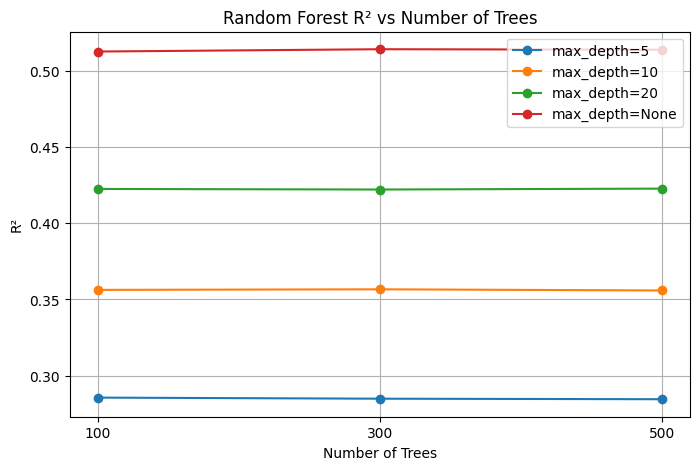

In [90]:
plt.figure(figsize=(8, 5))

for depth in df_results["max_depth"].unique():
    subset = df_results[df_results["max_depth"] == depth]
    plt.plot(subset["n_estimators"], subset["R2"], marker="o", label=f"max_depth={depth}")

plt.xticks([100, 300, 500])
plt.xlabel("Number of Trees")
plt.ylabel("R²")
plt.title("Random Forest R² vs Number of Trees")
plt.legend()
plt.grid(True)
plt.show()


For my second model, I used a Random Forest Regressor to predict NYC property sale prices. This model works by building many decision trees and averaging their predictions, which helps reduce overfitting and capture complex patterns in the data. I tested several combinations of hyperparameters, including different maximum tree depths (5, 10, 20, and unlimited) and different numbers of trees (100, 300, and 500). Across all these versions, the best-performing Random Forest had no maximum depth limit and used 300 trees. This model achieved an R² of approximately 0.514, indicating that it explained about 51% of the variation in sale prices. It also produced an MSE of roughly 65.1 billion and an RMSE of about $255,066.

Since the mean sale price in my dataset is about $667, 125this RMSE is around 38% of the average sale price. Overall, Model 2 demonstrates how ensemble methods like Random Forest can capture non-linear relationships and provide stable predictions across large datasets.

Comparing model 1 and model 2

The two predictive models I built—linear regression (Model 1) and Random Forest (Model 2)—performed differently on the NYC property sales dataset. Model 1, the full OLS regression with neighborhood dummy variables, achieved the stronger results, explaining about 57.9% of the variation in sale prices and producing the lowest RMSE. Model 2, the Random Forest model, also performed reasonably well, but its best version explained 51.4% of the variation and had a slightly higher prediction error. While the Random Forest was able to capture more complex, non-linear relationships, the linear regression model ultimately provided more accurate predictions for this dataset. Overall, Model 1 proved to be the better choice based on both R² and error metrics.

###KNN (k-nearest neighbors) classification

In [58]:
knn_c = clean_nyc.copy()
knn_c = knn_c[knn_c["sale_price"] > 0].copy()

In [59]:
knn_c["price_class"] = pd.qcut(knn_c["sale_price"],q=3,labels=["Low", "Mid", "High"])


In [62]:
feature_cols = ["gross_square_feet","land_square_feet","year_built","residential_units","commercial_units","total_units"]
feature_cols = [c for c in feature_cols if c in knn_c.columns]
knn_c = knn_c.dropna(subset=feature_cols + ["price_class"])

In [63]:
X = knn_c[feature_cols].copy()
y = knn_c["price_class"]

In [64]:
skewed_features = ["gross_square_feet", "land_square_feet"]

for c in skewed_features:
    if c in X.columns:
        X[c] = np.log1p(X[c])

In [65]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [66]:
scaler = StandardScaler()

x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [67]:
best_k = None
best_acc = -1

k_values = [3, 5, 7, 9, 11, 15, 21]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_s, y_train)

    pred = knn.predict(x_test_s)
    acc = accuracy_score(y_test, pred)

    print(f"k={k} accuracy={acc:.4f}")

    if acc > best_acc:
        best_k = k
        best_acc = acc

print("\nBest k:", best_k, "Best accuracy:", best_acc)

k=3 accuracy=0.4749
k=5 accuracy=0.4873
k=7 accuracy=0.4898
k=9 accuracy=0.4990
k=11 accuracy=0.5041
k=15 accuracy=0.5094
k=21 accuracy=0.5114

Best k: 21 Best accuracy: 0.5114332380563495


In [68]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train_s, y_train)

pred = knn.predict(x_test_s)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Confusion Matrix:
 [[1016  249  360]
 [ 364  848  426]
 [ 519  475  641]]

Classification Report:
               precision    recall  f1-score   support

        High       0.54      0.63      0.58      1625
         Low       0.54      0.52      0.53      1638
         Mid       0.45      0.39      0.42      1635

    accuracy                           0.51      4898
   macro avg       0.51      0.51      0.51      4898
weighted avg       0.51      0.51      0.51      4898



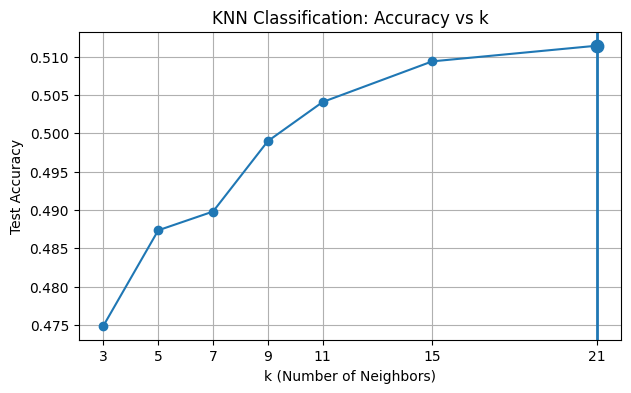

Best k: 21 Best accuracy: 0.5114332380563495


In [70]:
k_values = [3, 5, 7, 9, 11, 15, 21]
acc_values = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_s, y_train)

    pred = knn.predict(x_test_s)
    acc = accuracy_score(y_test, pred)
    acc_values.append(acc)

# Find best k
best_idx = int(np.argmax(acc_values))
best_k = k_values[best_idx]
best_acc = acc_values[best_idx]

# Line graph
plt.figure(figsize=(7, 4))
plt.plot(k_values, acc_values, marker="o")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Classification: Accuracy vs k")
plt.grid(True)

# Mark the best k
plt.xticks(k_values)
plt.axvline(best_k, linewidth=2)
plt.scatter([best_k], [best_acc], s=80)

plt.show()

print("Best k:", best_k, "Best accuracy:", best_acc)

For this analysis, I turned sale_price into a 3-class label (Low, Mid, High) using quantiles, so each class has about the same number of properties. Then I trained a K-Nearest Neighbors (KNN) classifier using numeric housing features (gross/land square feet, year built, and unit counts). Because KNN is distance-based, I applied a log transform to skewed square-footage features and used standardization (z-scores). I tested multiple values of k (number of neighbors) and plotted test accuracy vs k to choose the best-performing model.

Accuracy increased as k increased and then started to level off. The best model occurred at k = 21, with a test accuracy of ≈ 0.511. The confusion matrix and classification report show the model predicts High and Low price classes better than the Mid class: Best accuracy: ~51.1% (k=21), High: precision 0.54, recall 0.63, F1 0.58, Low: precision 0.54, recall 0.52, F1 0.53, Mid: precision 0.45, recall 0.39, F1 0.42

The model performs better than chance (~33% for three classes), but it struggles most with the Mid category because mid-priced homes overlap with both cheaper and more expensive properties. Adding stronger predictors like location (borough/ZIP/neighborhood) and building type would likely improve classification accuracy.

(with borough) k=3 accuracy=0.5553
(with borough) k=5 accuracy=0.5584
(with borough) k=7 accuracy=0.5690
(with borough) k=9 accuracy=0.5729
(with borough) k=11 accuracy=0.5747
(with borough) k=15 accuracy=0.5759
(with borough) k=21 accuracy=0.5774

(with borough) Best k: 21 Best accuracy: 0.5773785218456513


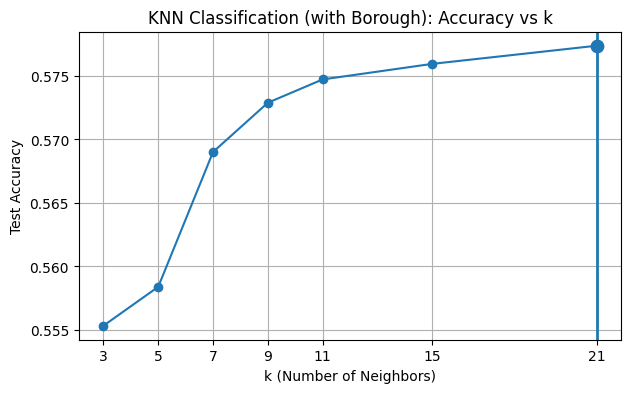


Confusion Matrix:
 [[1183  136  306]
 [ 301  888  449]
 [ 463  415  757]]

Classification Report:
               precision    recall  f1-score   support

        High       0.61      0.73      0.66      1625
         Low       0.62      0.54      0.58      1638
         Mid       0.50      0.46      0.48      1635

    accuracy                           0.58      4898
   macro avg       0.58      0.58      0.57      4898
weighted avg       0.58      0.58      0.57      4898



In [73]:
boro_col = "borough"

knn_c2 = knn_c.dropna(subset=feature_cols + [boro_col, "price_class"]).copy()

X = knn_c2[feature_cols + [boro_col]].copy()
y = knn_c2["price_class"]

for c in ["gross_square_feet", "land_square_feet"]:
    if c in X.columns:
        X[c] = np.log1p(X[c])

X = pd.get_dummies(X, columns=[boro_col], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s  = scaler.transform(x_test)


k_values = [3, 5, 7, 9, 11, 15, 21]
acc_values = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_s, y_train)

    pred = knn.predict(x_test_s)
    acc = accuracy_score(y_test, pred)
    acc_values.append(acc)

    print(f"(with borough) k={k} accuracy={acc:.4f}")

best_idx = int(np.argmax(acc_values))
best_k = k_values[best_idx]
best_acc = acc_values[best_idx]

print("\n(with borough) Best k:", best_k, "Best accuracy:", best_acc)

plt.figure(figsize=(7, 4))
plt.plot(k_values, acc_values, marker="o")
plt.xticks(k_values)
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Classification (with Borough): Accuracy vs k")
plt.grid(True)

plt.axvline(best_k, linewidth=2)
plt.scatter([best_k], [best_acc], s=80)

plt.show()

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(x_train_s, y_train)

final_pred = knn_final.predict(x_test_s)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, final_pred))
print("\nClassification Report:\n", classification_report(y_test, final_pred))


I built a K-Nearest Neighbors (KNN) classifier to predict whether a NYC property sale belongs to a Low, Mid, or High price category. I created these three classes by splitting sale_price into equal-sized groups using quantiles. I used numeric property features (square footage, year built, and unit counts), applied a log transform to reduce skew in square-footage variables, and standardized all features because KNN relies on distances. To improve performance, I added borough as a location feature using one-hot encoding, then tuned the model by testing different values of k and plotting test accuracy versus k.

The best-performing model used k = 21 and achieved a test accuracy of ≈ 0.577 (57.7%). Accuracy steadily increased as k increased and leveled off near k = 21. The confusion matrix and classification report show that the model predicts High and Low categories better than Mid:

Accuracy: ~57.7%

High: precision 0.61, recall 0.73, F1 0.66

Low: precision 0.62, recall 0.54, F1 0.58

Mid: precision 0.50, recall 0.46, F1 0.48

Adding borough improved classification because location strongly affects sale prices in NYC, and the model still finds the Mid category hardest due to overlap between neighboring price ranges.

###Permutation Test

Null hypothesis (H₀): There is no real difference in typical sale prices between the two boroughs.

Alternative hypothesis (H₁): There is a real difference in typical sale prices between the two boroughs.

In [79]:
boro_col = "borough"

g1_name = "1"
g2_name = "2"

In [80]:
perm_nyc = clean_nyc.copy()
perm_nyc = perm_nyc.dropna(subset=[boro_col, "sale_price"]).copy()
perm_nyc["sale_price"] = pd.to_numeric(perm_nyc["sale_price"], errors="coerce")
perm_nyc = perm_nyc.dropna(subset=["sale_price"])
perm_nyc = perm_nyc[perm_nyc["sale_price"] > 0].copy()
perm_nyc[boro_col] = perm_nyc[boro_col].astype(str).str.strip()

In [81]:
perm_nyc["log_price"] = np.log1p(perm_nyc["sale_price"])

In [82]:
perm_nyc = perm_nyc[perm_nyc[boro_col].isin([g1_name, g2_name])].copy()

In [83]:
data_g1_mean = perm_nyc[perm_nyc[boro_col] == g1_name]["log_price"].mean()
data_g2_mean = perm_nyc[perm_nyc[boro_col] == g2_name]["log_price"].mean()

data_test_statistic = abs(data_g1_mean - data_g2_mean)
print("Group sizes:", (perm_nyc[boro_col] == g1_name).sum(), (perm_nyc[boro_col] == g2_name).sum())
print("Data test statistic:", data_test_statistic)

Group sizes: 108 2995
Data test statistic: 0.8530241835077703


In [85]:
abs_diff_list = []
B = 10000

for i in range(B):
    perm_nyc["permuted_boro"] = np.random.permutation(perm_nyc[boro_col])

    sim_g1_median = perm_nyc.loc[perm_nyc["permuted_boro"] == g1_name, "log_price"].median()
    sim_g2_median = perm_nyc.loc[perm_nyc["permuted_boro"] == g2_name, "log_price"].median()

    abs_diff_list.append(abs(sim_g1_median - sim_g2_median))

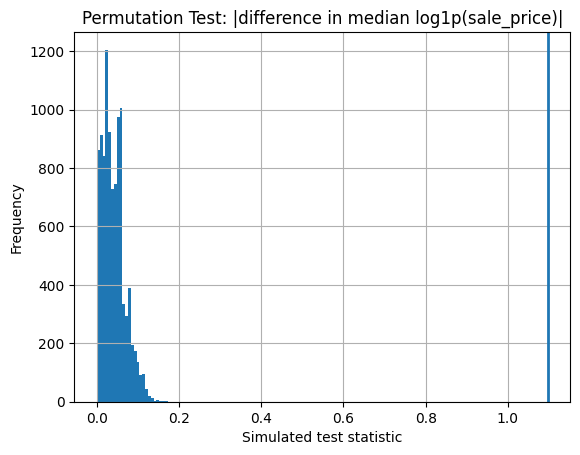

In [86]:
pd.Series(abs_diff_list).hist(bins=25)
plt.axvline(data_test_statistic, linewidth=2)
plt.title("Permutation Test: |difference in median log1p(sale_price)|")
plt.xlabel("Simulated test statistic")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In the histogram of simulated test statistics, most permuted differences were small and clustered close to 0. However, the observed statistic from the real data (≈ 0.8530) was far larger than almost all values produced under the null hypothesis. That means it would be extremely unlikely to observe a difference this large if the borough labels truly had no relationship to sale prices. Because the observed statistic falls in the extreme tail of the null distribution, and we reject the null hypothesis.

I used a permutation test to compare typical sale prices between borough 1 and borough 2. Because sale prices are highly skewed, I used log1p(sale_price) and compared the median values. My test statistic was the absolute difference in medians. I then shuffled the borough labels 10,000 times to simulate the null distribution.

The observed test statistic was |median(log1p(price))₁ − median(log1p(price))₂| = 1.0972. In the histogram of simulated statistics, almost all values under the null hypothesis fall near 0–0.2, while the observed statistic lies far to the right.

Since the observed statistic is far outside the null distribution, we reject the null hypothesis and conclude that borough 1 and borough 2 have statistically different typical sale prices.